In [2]:
# Put this in the FIRST cell of the notebook
import sys, os
from pathlib import Path

def find_root(markers=("configs/rescontact.yaml", "src", "scripts")):
    p = Path.cwd()
    while True:
        if all((p/m).exists() for m in markers):
            return p
        if p.parent == p:
            raise RuntimeError("Project root not found from", Path.cwd())
        p = p.parent

ROOT = find_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("Project root:", ROOT)
print("Added to sys.path:", SRC)


Project root: /Users/ryoji/Documents/Code/Python/Prot_Eng/Res-contact
Added to sys.path: /Users/ryoji/Documents/Code/Python/Prot_Eng/Res-contact/src


Device: mps
Loaded: /Users/ryoji/Documents/Code/Python/Prot_Eng/Res-contact/checkpoints/model_best.pt
Model flavor detected: old_simple
Resolved test_dir: /Users/ryoji/Documents/Code/Python/Prot_Eng/Res-contact/data/pdb/test exists? True
Found 500 structure files.
[rescontact/ds] enumerated 500 examples under /Users/ryoji/Documents/Code/Python/Prot_Eng/Res-contact/data/pdb/test
Dataset size: 500


/var/folders/77/wfv9nbcd5t94hwcgvb3vzvwr0000gn/T/ipykernel_74518/4175568836.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=D

[rescontact/ESM] init model_id=facebook/esm2_t6_8M_UR50D cache=/Users/ryoji/Documents/Code/Python/Prot_Eng/Res-contact/.cache/rescontact/emb device=mps


/opt/miniconda3/envs/.env_res_contact/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/miniconda3/envs/.env_res_contact/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/miniconda3/envs/.env_res_contact/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/miniconda3/envs/.env_res_contact/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/.env_res_contact/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/.env_res_contact/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/.env_res_contact/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, 

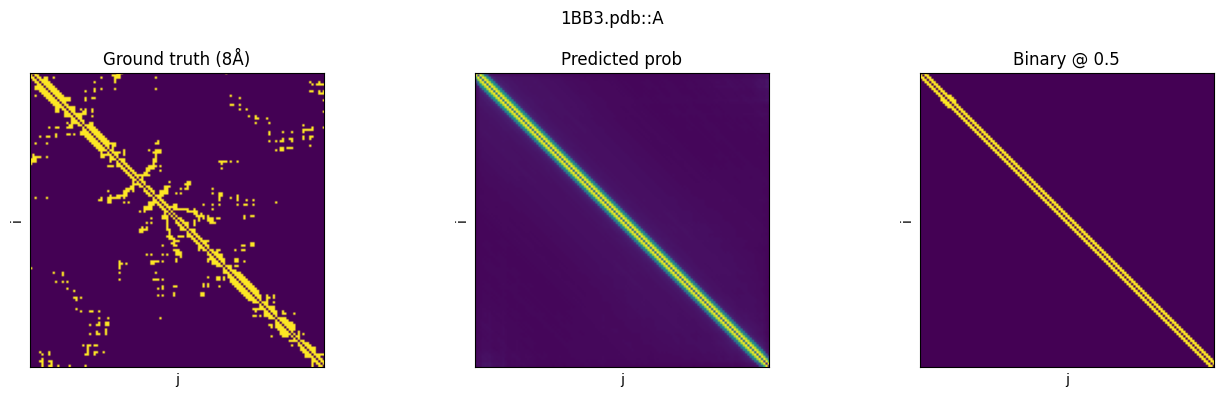

Saved: /Users/ryoji/Documents/Code/Python/Prot_Eng/Res-contact/heatmap.png


In [4]:
# %% [markdown]
# Visualize a single test example: ground truth vs predicted contact map

# %%
import os, io, base64, math
from pathlib import Path

import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------- locate repo root (reuse ROOT if you already set it) ----------
try:
    ROOT  # defined in the first cell
except NameError:
    def find_root(markers=("configs/rescontact.yaml", "src", "scripts")):
        p = Path.cwd()
        while True:
            if all((p/m).exists() for m in markers):
                return p
            if p.parent == p:
                raise RuntimeError("Project root not found from", Path.cwd())
            p = p.parent
    ROOT = find_root()

# ---------- load config ----------
CFG = yaml.safe_load(open(ROOT / "configs/rescontact.yaml"))

# ---------- device ----------
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", DEVICE)

# ---------- choose model class & state-dict adapter ----------
from types import SimpleNamespace

def build_model_for_state(want_dim:int, hidden_dim:int, dist_bias:int, state_dict:dict):
    """Return a model instance that matches the checkpoint (old Simple or new Bilinear)."""
    has_old = any(k.startswith("proj.weight") for k in state_dict.keys()) and "bilin.weight" in state_dict
    has_new = any(k.startswith("proj.0.weight") for k in state_dict.keys()) or "bilinear.weight" in state_dict

    if has_old and not has_new:
        # Old: SimpleContactNet(proj Linear, bilin Linear, dist_bias Embedding)
        import torch.nn as nn
        class SimpleContactNet(nn.Module):
            def __init__(self, embed_dim, hidden_dim, distance_bias_max=512):
                super().__init__()
                self.proj = nn.Linear(embed_dim, hidden_dim)
                self.act  = nn.ReLU()
                self.bilin = nn.Linear(hidden_dim, hidden_dim, bias=False)
                self.dist_bias = nn.Embedding(distance_bias_max, 1)
            def forward(self, emb):
                z = self.act(self.proj(emb))                  # [B,L,H]
                zW = self.bilin(z)
                logits = torch.einsum("blh,bmh->blm", zW, z) / math.sqrt(z.shape[-1])
                B, L, _ = logits.shape
                idx = torch.arange(L, device=logits.device)
                dist = (idx[None,:] - idx[:,None]).abs().clamp_max(self.dist_bias.num_embeddings - 1)
                db = self.dist_bias(dist)[:, :, 0]
                return logits + db.unsqueeze(0)
        return SimpleNamespace(kind="old_simple", model=SimpleContactNet(want_dim, hidden_dim, dist_bias))

    # New style (BilinearContactNet) — try to import, else fall back to a compatible definition
    try:
        from rescontact.models.contact_net import BilinearContactNet
        model = BilinearContactNet(embed_dim=want_dim, hidden_dim=hidden_dim, distance_bias_max=dist_bias)
        return SimpleNamespace(kind="new_bilinear", model=model)
    except Exception:
        import torch.nn as nn
        class BilinearCompat(nn.Module):
            def __init__(self, embed_dim, hidden_dim, distance_bias_max=512):
                super().__init__()
                # mimic a tiny MLP block names used by newer checkpoints
                self.proj = nn.Sequential(
                    nn.Linear(embed_dim, hidden_dim),  # proj.0
                    nn.ReLU(),                         # proj.1
                    nn.Dropout(p=0.0),                 # proj.2 (exists with no params)
                    nn.Linear(hidden_dim, hidden_dim)  # proj.3
                )
                self.bilinear = nn.Linear(hidden_dim, hidden_dim, bias=False)
                self.dist_bias = nn.Embedding(distance_bias_max, 1)
            def forward(self, emb):
                z = self.proj(emb)
                zW = self.bilinear(z)
                logits = torch.einsum("blh,bmh->blm", zW, z) / math.sqrt(z.shape[-1])
                B, L, _ = logits.shape
                idx = torch.arange(L, device=logits.device)
                dist = (idx[None,:] - idx[:,None]).abs().clamp_max(self.dist_bias.num_embeddings - 1)
                db = self.dist_bias(dist)[:, :, 0]
                return logits + db.unsqueeze(0)
        return SimpleNamespace(kind="compat_bilinear", model=BilinearCompat(want_dim, hidden_dim, dist_bias))

# ---------- load checkpoint ----------
want_dim   = int(CFG["model"]["embed_dim"])
hidden_dim = int(CFG["model"]["hidden_dim"])
dist_bias  = int(CFG["model"]["distance_bias_max"])

ckpt_path = (ROOT / CFG["paths"]["ckpt_dir"]) / "model_best.pt"
state = torch.load(ckpt_path, map_location=DEVICE)
state_dict = state.get("model") or state.get("state_dict") or state

bundle = build_model_for_state(want_dim, hidden_dim, dist_bias, state_dict)
model  = bundle.model.to(DEVICE).eval()

# If key names differ slightly (e.g., 'bilin' -> 'bilinear', 'proj.' -> 'proj.0.')
def _remap_keys(sd:dict):
    out = {}
    for k,v in sd.items():
        nk = k
        if nk.startswith("bilin."):
            nk = nk.replace("bilin.", "bilinear.")
        # map flat proj -> first layer of seq for minimal viability
        if nk == "proj.weight": nk = "proj.0.weight"
        if nk == "proj.bias":   nk = "proj.0.bias"
        out[nk] = v
    return out

loaded = False
missing = unexpected = []
try:
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    loaded = True
except RuntimeError:
    fixed = _remap_keys(state_dict)
    missing, unexpected = model.load_state_dict(fixed, strict=False)
    loaded = True

print(f"Loaded: {ckpt_path}")
if missing:    print("  missing keys:", list(missing))
if unexpected: print("  unexpected keys:", list(unexpected))
print("Model flavor detected:", bundle.kind)

# ---------- resolve test_dir and verify files ----------
test_dir = (ROOT / CFG["paths"]["test_dir"]).resolve()
print("Resolved test_dir:", test_dir, "exists?", test_dir.exists())

def list_structs(base:Path):
    pats = ("*.pdb","*.cif","*.mmcif","*.PDB","*.CIF","*.MMCIF")
    files = []
    for pat in pats:
        files += list(base.rglob(pat))
    return files

files = list_structs(test_dir)
print(f"Found {len(files)} structure files.")
if not files:
    raise AssertionError(f"No test structures found under {test_dir}. "
                         f"Put *.pdb/*.cif/*.mmcif files there or update CFG paths.")

# ---------- dataset ----------
from rescontact.data.dataset import PDBContactDataset

ds = PDBContactDataset(
    root_dir=str(test_dir),
    cache_dir=str((ROOT / CFG["paths"]["cache_dir"]).resolve()),
    contact_threshold=CFG["labels"]["contact_threshold_angstrom"],
    include_inter_chain=CFG["labels"]["include_inter_chain"],
    esm_model_name=CFG["model"]["esm_model"],
    use_msa=bool(CFG["features"]["use_msa"]),
    msa_cfg=CFG["features"]["msa"],
    device=DEVICE,  # ensure ESM runs on the chosen device
)

print("Dataset size:", len(ds))
assert len(ds) > 0, "No test structures found by dataset enumeration."

# ---------- prepare one example ----------
item_idx = 0  # change to visualize another protein
item = ds[item_idx]

def _align_embed_dim(x: torch.Tensor, want: int) -> torch.Tensor:
    got = x.shape[-1]
    if got == want: return x
    if got < want:
        pad = want - got
        return torch.cat([x, x.new_zeros(*x.shape[:-1], pad)], dim=-1)
    return x[..., :want]

emb  = torch.as_tensor(item["emb"]).unsqueeze(0).float().to(DEVICE)  # [1,L,D]
emb  = _align_embed_dim(emb, want_dim)
y    = torch.as_tensor(item["contacts"]).float().cpu().numpy()       # [L,L]
mask = torch.as_tensor(item["mask"]).float().cpu().numpy()           # [L,L]

with torch.no_grad():
    logits = model(emb).detach().cpu().numpy()[0]                    # [L,L]
probs = 1.0 / (1.0 + np.exp(-logits))

# ---------- visualize ----------
thr = float(CFG["inference"].get("threshold", 0.5))
pred_bin = (probs >= thr).astype(np.float32) * mask
L = probs.shape[0]

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
ax[0].imshow(y, vmin=0, vmax=1);        ax[0].set_title("Ground truth (8Å)")
ax[1].imshow(probs, vmin=0, vmax=1);    ax[1].set_title("Predicted prob")
ax[2].imshow(pred_bin, vmin=0, vmax=1); ax[2].set_title(f"Binary @ {thr}")

for a in ax:
    a.set_xticks([]); a.set_yticks([])
    a.set_xlabel("j"); a.set_ylabel("i")
title = item.get("id","?")
fig.suptitle(title); plt.tight_layout()
plt.show()

# save a clean PNG
out_png = ROOT / "heatmap.png"
fig.savefig(out_png, dpi=150)
print("Saved:", out_png)
